# Airline Delay Analysis (Beginner-Friendly EDA)

This notebook explains the 2025 airline-delay results using four main libraries:

- **pandas** loads and filters the tables.
- **NumPy** performs small numerical calculations.
- **Matplotlib** controls chart labels and layout.
- **Seaborn** creates the charts.

The large raw files have already been cleaned and summarized by the project pipeline. Reading the summary tables here keeps the EDA short, fast, and easy to explain while preserving the same results.

## 1. Import the libraries and set the folders

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# This works when Jupyter starts in either the project folder or notebooks folder.
PROJECT_FOLDER = Path.cwd()
if PROJECT_FOLDER.name == "notebooks":
    PROJECT_FOLDER = PROJECT_FOLDER.parent

TABLE_FOLDER = PROJECT_FOLDER / "reports" / "tables"
FIGURE_FOLDER = PROJECT_FOLDER / "reports" / "figures"
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 20)

Matplotlib is building the font cache; this may take a moment.


## 2. Load the prepared EDA tables

Each CSV is a normal pandas DataFrame. The tables contain the same results produced from all 7,001,619 raw flight rows.

In [2]:
overall = pd.read_csv(TABLE_FOLDER / "overall_summary.csv")
monthly = pd.read_csv(TABLE_FOLDER / "monthly_performance.csv")
time_bands = pd.read_csv(TABLE_FOLDER / "departure_time_band_performance.csv")
airlines = pd.read_csv(TABLE_FOLDER / "airline_performance.csv")
routes = pd.read_csv(TABLE_FOLDER / "route_performance.csv")
causes = pd.read_csv(TABLE_FOLDER / "delay_cause_summary.csv")

print("Tables loaded successfully")
print("Months:", len(monthly), "| Airlines:", len(airlines), "| Routes:", len(routes))

Tables loaded successfully
Months: 12 | Airlines: 14 | Routes: 6938


## 3. Overall performance

A severe delay means an arrival delay of **more than 60 minutes**. Cancelled, diverted, and unknown arrival outcomes are not labelled as severe or non-severe.

In [3]:
# Change the two-column table into an easy metric lookup.
metrics = overall.set_index("metric")["value"]

overall_display = pd.DataFrame({
    "Measure": [
        "Scheduled flights",
        "Cancelled flights",
        "Diverted flights",
        "Average arrival delay (minutes)",
        "Median arrival delay (minutes)",
        "Severe-delay rate",
        "On-time/early rate",
    ],
    "Value": [
        f"{metrics['total_flights']:,.0f}",
        f"{metrics['cancelled_flights']:,.0f}",
        f"{metrics['diverted_flights']:,.0f}",
        f"{metrics['average_arrival_delay_minutes']:.2f}",
        f"{metrics['median_arrival_delay_minutes']:.2f}",
        f"{metrics['severe_delay_rate']:.2%}",
        f"{metrics['on_time_early_rate']:.2%}",
    ],
})
overall_display

,Measure,Value
0,Scheduled flights,"7,001,619"
1,Cancelled flights,"102,876"
2,Diverted flights,"19,258"
3,Average arrival delay (minutes),8.50
4,Median arrival delay (minutes),-6.00
5,Severe-delay rate,8.04%
6,On-time/early rate,62.43%


## 4. Monthly flight volume and severe delays

The bars show how many flights were scheduled. The line shows the percentage of eligible flights that arrived more than 60 minutes late.

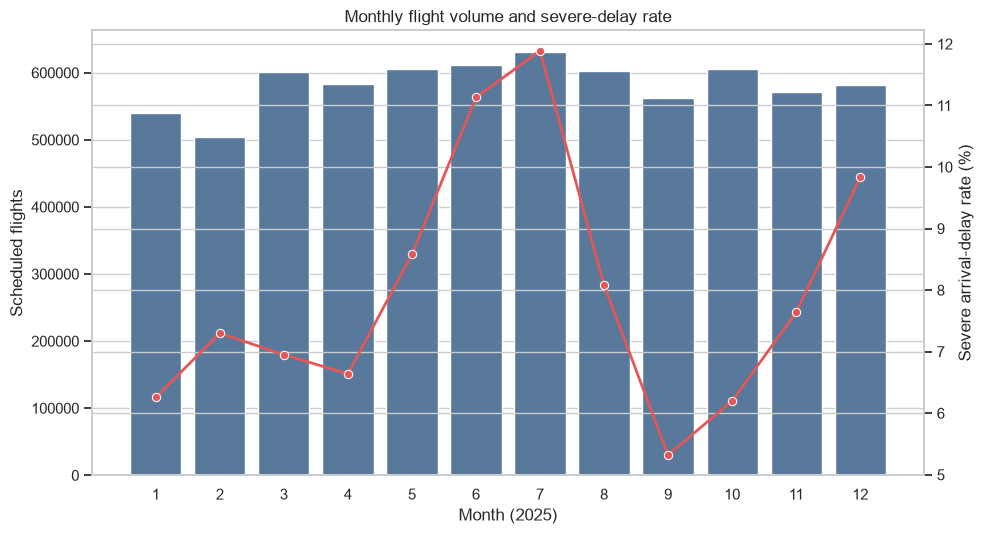

In [4]:
monthly = monthly.sort_values("month").copy()
monthly["severe_delay_percent"] = np.round(monthly["severe_delay_rate"] * 100, 2)

fig, ax1 = plt.subplots(figsize=(10, 5.5))
sns.barplot(data=monthly, x="month", y="total_flights", color="#4C78A8", ax=ax1)
ax1.set(xlabel="Month (2025)", ylabel="Scheduled flights")

ax2 = ax1.twinx()
sns.lineplot(data=monthly, x=np.arange(12), y="severe_delay_percent",
             color="#E45756", marker="o", linewidth=2, ax=ax2)
ax2.set_ylabel("Severe arrival-delay rate (%)")
plt.title("Monthly flight volume and severe-delay rate")
fig.tight_layout()
fig.savefig(FIGURE_FOLDER / "monthly_volume_and_severe_delay.png", dpi=160)
plt.show()

In [5]:
worst_month = monthly.loc[monthly["severe_delay_rate"].idxmax()]
print(
    f"Month {int(worst_month['month'])} had the highest severe-delay rate: "
    f"{worst_month['severe_delay_rate']:.2%}."
)

Month 7 had the highest severe-delay rate: 11.89%.


## 5. Does departure time matter?

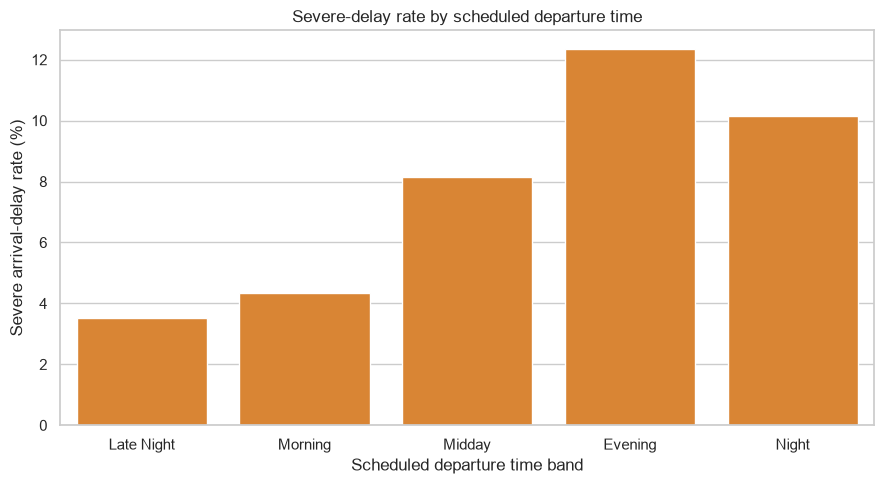

In [6]:
band_order = ["Late Night", "Morning", "Midday", "Evening", "Night"]
time_bands["severe_delay_percent"] = np.round(time_bands["severe_delay_rate"] * 100, 2)

plt.figure(figsize=(9, 5))
sns.barplot(data=time_bands, x="departure_time_band", y="severe_delay_percent",
            order=band_order, color="#F58518")
plt.xlabel("Scheduled departure time band")
plt.ylabel("Severe arrival-delay rate (%)")
plt.title("Severe-delay rate by scheduled departure time")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER / "severe_delay_by_departure_band.png", dpi=160)
plt.show()

In [7]:
worst_band = time_bands.loc[time_bands["severe_delay_rate"].idxmax()]
print(
    f"{worst_band['departure_time_band']} flights had the highest severe-delay rate: "
    f"{worst_band['severe_delay_rate']:.2%}."
)

Evening flights had the highest severe-delay rate: 12.34%.


## 6. Compare airlines

Only airlines with at least 10,000 flights are included, so a very small airline cannot rank first because of only a few unusual flights.

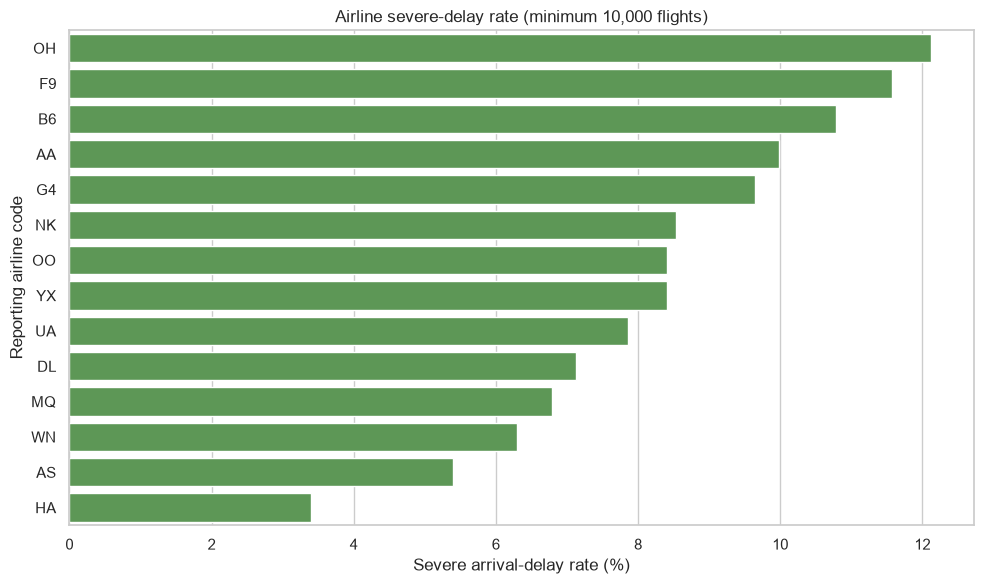

In [8]:
large_airlines = airlines[airlines["total_flights"] >= 10_000].copy()
large_airlines["severe_delay_percent"] = np.round(large_airlines["severe_delay_rate"] * 100, 2)
large_airlines = large_airlines.sort_values("severe_delay_percent", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=large_airlines, x="severe_delay_percent", y="reporting_airline",
            color="#54A24B")
plt.xlabel("Severe arrival-delay rate (%)")
plt.ylabel("Reporting airline code")
plt.title("Airline severe-delay rate (minimum 10,000 flights)")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER / "airline_severe_delay_rate.png", dpi=160)
plt.show()

In [9]:
worst_airline = large_airlines.iloc[0]
print(
    f"Airline {worst_airline['reporting_airline']} had the highest severe-delay rate: "
    f"{worst_airline['severe_delay_rate']:.2%}."
)

Airline OH had the highest severe-delay rate: 12.12%.


## 7. Compare busy routes

The same fairness idea is used here: only routes with at least 1,000 flights are compared.

In [10]:
busy_routes = routes[routes["total_flights"] >= 1_000].copy()
busy_routes = busy_routes.sort_values("severe_delay_rate", ascending=False)

top_routes = busy_routes[["route", "total_flights", "severe_delay_rate"]].head(10).copy()
top_routes["severe_delay_rate"] = top_routes["severe_delay_rate"].map(lambda value: f"{value:.2%}")
top_routes

,route,total_flights,severe_delay_rate
155,ASE-DFW,1178,19.15%
1587,DCA-SAV,1074,18.53%
1541,DCA-HPN,1359,18.40%
2816,HPN-DCA,1359,17.68%
5543,RDU-EWR,1848,16.96%
1601,DCA-TYS,1033,16.91%
2876,IAD-EWR,1499,16.87%
1910,DFW-MSN,1094,16.62%
4735,ORD-EWR,5990,16.56%
208,ATL-EWR,6105,16.51%


## 8. Which reported causes contributed the most delay minutes?

These cause fields are useful for description, but they happen after the delay and should not be used to predict a delay before departure.

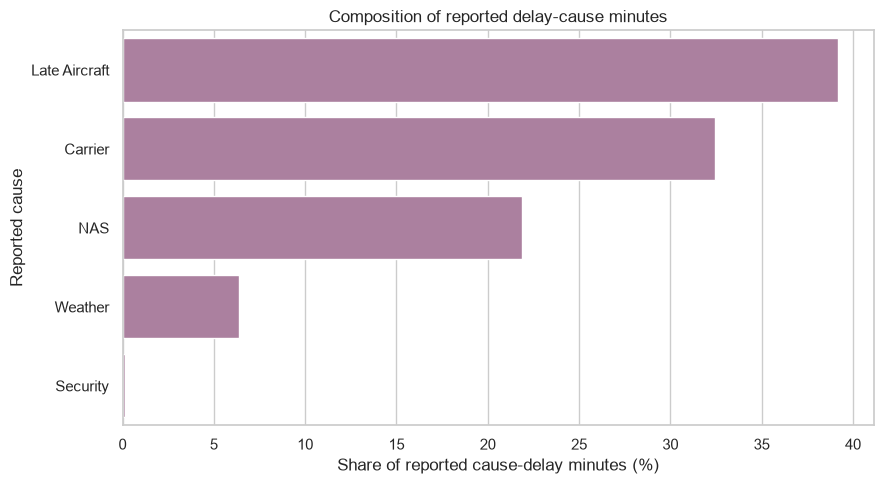

In [11]:
causes["share_percent"] = np.round(causes["share_of_reported_cause_minutes"] * 100, 2)
causes = causes.sort_values("share_percent", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=causes, x="share_percent", y="cause", color="#B279A2")
plt.xlabel("Share of reported cause-delay minutes (%)")
plt.ylabel("Reported cause")
plt.title("Composition of reported delay-cause minutes")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER / "reported_delay_cause_share.png", dpi=160)
plt.show()

## 9. Final findings

This last cell calculates the conclusions from the tables instead of typing the answers manually.

In [12]:
worst_route = busy_routes.iloc[0]
top_cause = causes.iloc[0]

findings = [
    f"1. Month {int(worst_month['month'])} had the highest severe-delay rate ({worst_month['severe_delay_rate']:.2%}).",
    f"2. {worst_band['departure_time_band']} departures had the highest severe-delay rate ({worst_band['severe_delay_rate']:.2%}).",
    f"3. Airline {worst_airline['reporting_airline']} ranked highest among airlines with at least 10,000 flights ({worst_airline['severe_delay_rate']:.2%}).",
    f"4. Route {worst_route['route']} ranked highest among routes with at least 1,000 flights ({worst_route['severe_delay_rate']:.2%}).",
    f"5. {top_cause['cause']} made up the largest share of reported cause-delay minutes ({top_cause['share_of_reported_cause_minutes']:.2%}).",
]

print("\n".join(findings))

1. Month 7 had the highest severe-delay rate (11.89%).
2. Evening departures had the highest severe-delay rate (12.34%).
3. Airline OH ranked highest among airlines with at least 10,000 flights (12.12%).
4. Route ASE-DFW ranked highest among routes with at least 1,000 flights (19.15%).
5. Late Aircraft made up the largest share of reported cause-delay minutes (39.19%).


## Limitations

- The data covers only 2025, so it cannot show year-over-year trends.
- Airline codes are not expanded into airline names yet.
- The charts show associations, not proof that one factor causes another.
- Reported delay causes are descriptive and are not safe pre-departure ML features.